In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import plotly.graph_objects as go
import plotly.express as px
import dash
import dash_bootstrap_components as dbc

from plotly.subplots import make_subplots
from dash import dcc, html, Input, Output
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [8]:
file_path = r"C:\Users\hp\OneDrive\Desktop\anshnew\infosys\nsl-kdd\KDDTest+.txt"
df = pd.read_csv(file_path, header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [9]:
# Column names (41 features)
feature_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate"
]

In [10]:
df.columns = feature_names + ["attack", "difficulty_level"]
columns = feature_names + ["attack", "difficulty_level"]

df.columns = columns

df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,difficulty_level
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [11]:
dos_attacks = ['back','land','neptune','pod','smurf','teardrop','apache2',
               'mailbomb','processtable','udpstorm','worm']
probe_attacks = ['satan','ipsweep','nmap','portsweep','mscan','saint']
r2l_attacks = ['guess_passwd','ftp_write','imap','phf','multihop','warezmaster',
               'warezclient','spy','xlock','xsnoop','snmpgetattack','snmpguess',
               'httptunnel','sendmail','named']
u2r_attacks = ['rootkit','perl','loadmodule','ps','sqlattack','buffer_overflow']

def map_attack_category(label: str) -> str:
    if label in dos_attacks:
        return "DoS"
    elif label in probe_attacks:
        return "Probe"
    elif label in r2l_attacks:
        return "R2L"
    elif label in u2r_attacks:
        return "U2R"
    else:
        return "Normal"

df["attack_category"] = df["attack"].apply(map_attack_category)
df["binary_label"] = df["attack_category"].apply(lambda x: 0 if x == "Normal" else 1)   


print("\n=== ATTACK CATEGORY DISTRIBUTION ===")
print(df["attack_category"].value_counts())
print("\nAttack Category Shape:", df["attack_category"].shape)


=== ATTACK CATEGORY DISTRIBUTION ===
attack_category
Normal    9724
DoS       7460
R2L       2885
Probe     2421
U2R         54
Name: count, dtype: int64

Attack Category Shape: (22544,)


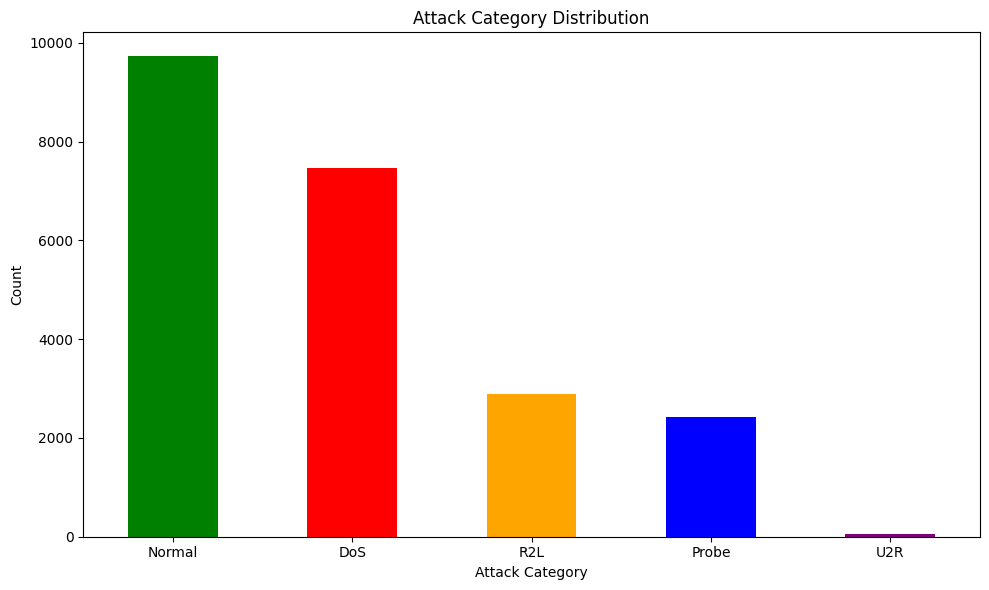

In [14]:
plt.figure(figsize=(10, 6))
df["attack_category"].value_counts().plot(kind="bar", color=['green', 'red', 'orange', 'blue', 'purple'])
plt.xlabel("Attack Category")
plt.ylabel("Count")
plt.title("Attack Category Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
df["attack_category"] = df["attack"].apply(map_attack_category)
df[["attack", "attack_category"]].head()

,attack,attack_category
0,neptune,DoS
1,neptune,DoS
2,normal,Normal
3,saint,Probe
4,mscan,Probe


In [16]:
print("\n=== DATA CLEANING ===")
print("Original shape:", df.shape)

# Remove duplicates
df.drop_duplicates(inplace=True)
print("After removing duplicates:", df.shape)

# Drop irrelevant columns
irrelevant_cols = ["num_outbound_cmds", "is_host_login", "difficulty_level"]
df.drop(columns=[col for col in irrelevant_cols if col in df.columns], inplace=True)
print("After dropping irrelevant columns:", df.shape)

# Handle missing values
print("\nMissing values before:")
print(df.isnull().sum()[df.isnull().sum() > 0])

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

print("Missing values handled successfully!")
print("Missing values after:")
print(df.isnull().sum().sum())


=== DATA CLEANING ===
Original shape: (22544, 45)
After removing duplicates: (22544, 45)
After dropping irrelevant columns: (22544, 42)

Missing values before:
Series([], dtype: int64)
Missing values handled successfully!
Missing values after:
0


In [17]:
# **EXPLICIT FEATURE CATEGORIZATION**
categorical_features = ["protocol_type", "service", "flag"]
numeric_features = [
    "duration", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent", 
    "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", 
    "su_attempted", "num_root", "num_file_creations", "num_shells", 
    "num_access_files", "is_guest_login", "count", "srv_count", "serror_rate", 
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate", 
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", 
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate"
]

# Verify all features exist
categorical_features = [col for col in categorical_features if col in df.columns]
numeric_features = [col for col in numeric_features if col in df.columns]

print(f"\n=== FEATURE SUMMARY ===")
print(f"Total features: {len(categorical_features) + len(numeric_features)}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numeric features ({len(numeric_features)}): {len(numeric_features)}")

# Separate features and target
X = df.drop(["attack", "attack_category", "binary_label"], axis=1)
y = df["attack_category"]

print(f"\nX shape: {X.shape}, y shape: {y.shape}")


=== FEATURE SUMMARY ===
Total features: 39
Categorical features (3): ['protocol_type', 'service', 'flag']
Numeric features (36): 36

X shape: (22544, 39), y shape: (22544,)


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),      # Scale numeric features
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)  # Encode categorical
    ],
    remainder="drop"  # Drop any remaining columns
)

# Apply transformation
X_processed = preprocessor.fit_transform(X)
print(f"\nShape after preprocessing: {X_processed.shape}")


Shape after preprocessing: (22544, 114)


In [19]:
# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_processed, y, test_size=0.20, random_state=42, stratify=y
)

# Second split: 75% train (of 80%), 25% val (of 80%) → 60/20/20 overall
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"\n=== FINAL SPLIT ===")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Train type: {type(X_train)}")  # numpy.ndarray
print(f"y_train distribution:\n{y_train.value_counts()}")

print("\n✅ Pipeline complete! Ready for model training.")


=== FINAL SPLIT ===
Train shape: (13526, 114)
Test shape: (4509, 114)
Train type: <class 'numpy.ndarray'>
y_train distribution:
attack_category
Normal    5834
DoS       4476
R2L       1731
Probe     1453
U2R         32
Name: count, dtype: int64

✅ Pipeline complete! Ready for model training.


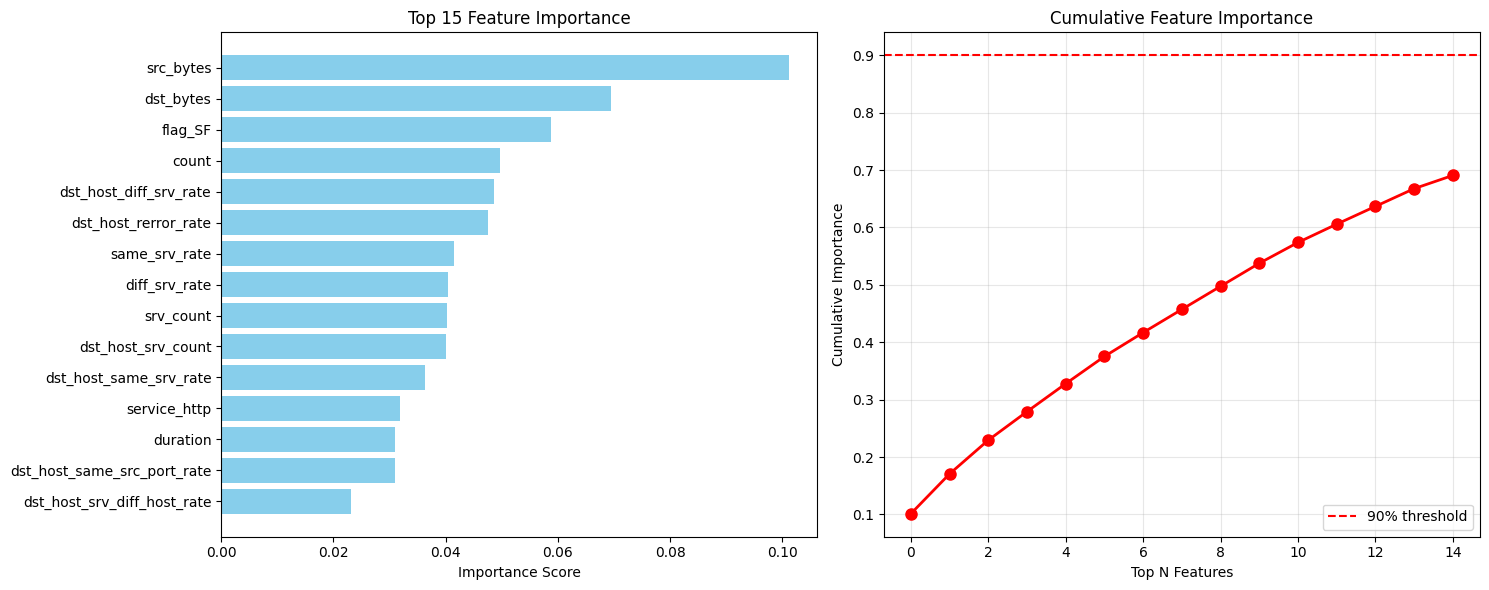

In [21]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd

# Quick Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

feature_names = (numeric_features + 
                list(preprocessor.named_transformers_['cat']
                     .get_feature_names_out(categorical_features)))

importance_df = pd.DataFrame({
    'feature': feature_names, 
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

# -----------------------------
# GRAPHS (No Emoji Warnings)
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.barh(range(15), importance_df['importance'], color='skyblue')
ax1.set_yticks(range(15))
ax1.set_yticklabels(importance_df['feature'], fontsize=10)
ax1.set_xlabel('Importance Score')
ax1.set_title('Top 15 Feature Importance')  # ✅ No emoji
ax1.invert_yaxis()

cumsum = importance_df['importance'].cumsum()
ax2.plot(range(15), cumsum, 'ro-', linewidth=2, markersize=8)
ax2.axhline(y=0.9, color='r', linestyle='--', label='90% threshold')
ax2.set_xlabel('Top N Features')
ax2.set_ylabel('Cumulative Importance')
ax2.set_title('Cumulative Feature Importance')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. FEATURE ENGINEERING
# -----------------------------
# A. Total Traffic Volume (Bytes)
df["total_bytes"] = df["src_bytes"] + df["dst_bytes"]

# B. Source-to-Destination Ratio (Data Exfiltration Indicator)
# We add +1 to avoid 'division by zero' errors
df["byte_ratio"] = (df["src_bytes"] + 1) / (df["dst_bytes"] + 1)

# C. Total Error Rate (Aggregated packet failures)
df["total_error_rate"] = (df["serror_rate"] + df["rerror_rate"] + 
                          df["srv_serror_rate"] + df["srv_rerror_rate"]) / 4

# Update numeric features list
new_features = ["total_bytes", "byte_ratio", "total_error_rate"]
for f in new_features:
    if f not in numeric_features:
        numeric_features.append(f)

print(f"✅ Added {len(new_features)} new features.")
print(f"Total Numeric Features: {len(numeric_features)}")

✅ Added 3 new features.
Total Numeric Features: 39



⚠️ TOP 10 REDUNDANT FEATURE PAIRS (>95% match):
           Feature 1        Feature 2  Correlation
72         src_bytes      total_bytes     0.999002
308  num_compromised         num_root     0.995960
588      rerror_rate  srv_rerror_rate     0.975535
551      serror_rate  srv_serror_rate     0.966375


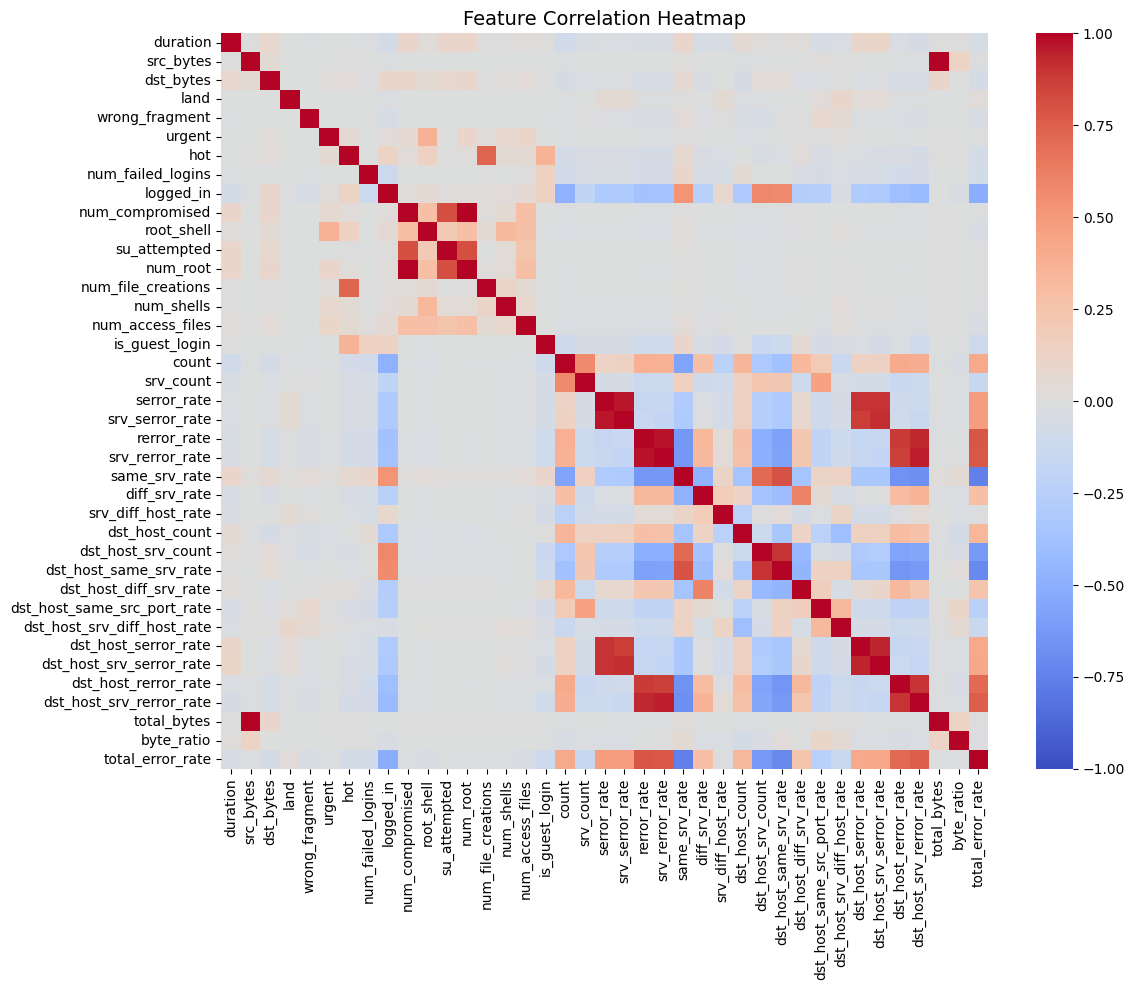

In [23]:
corr_matrix = df[numeric_features].corr()

# Identify Highly Correlated Pairs (> 0.95)
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
high_corr = corr_matrix.where(mask).stack().reset_index()
high_corr.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Filter absolute correlation > 0.95
redundant_pairs = high_corr[high_corr['Correlation'].abs() > 0.95].sort_values('Correlation', ascending=False)

print("\n⚠️ TOP 10 REDUNDANT FEATURE PAIRS (>95% match):")
print(redundant_pairs.head(10))

# -----------------------------
# 3. VISUALIZATION (HEATMAP)
# -----------------------------
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, vmax=1, vmin=-1)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

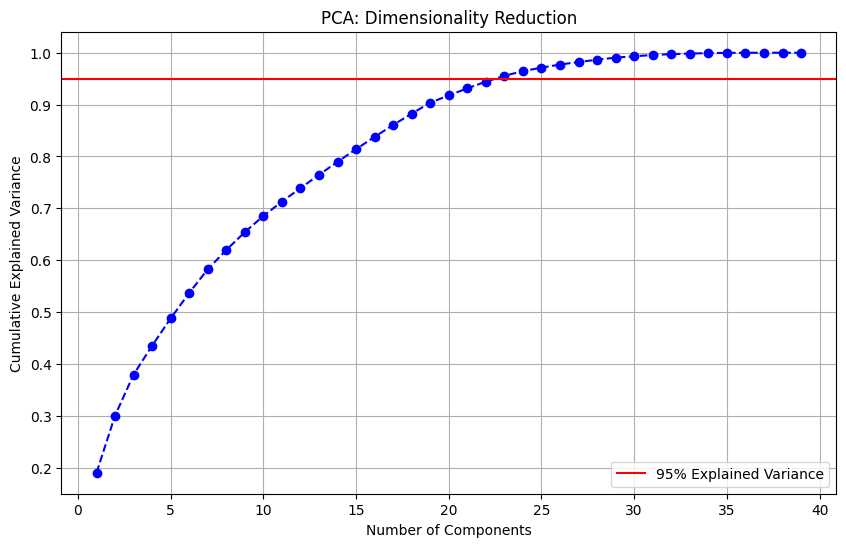

📊 PCA RESULTS:
Original Numeric Features: 39
Components needed for 95% variance: 23
🔥 Reduction: We can remove 16 dimensions and still keep 95% of the data's logic.


In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# -----------------------------
# PREPARE DATA FOR PCA
# -----------------------------
# PCA requires scaling first! (Large numbers dominate otherwise)
X_num = df[numeric_features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# -----------------------------
# FIT PCA
# -----------------------------
# We fit with all components first to see how much they explain
pca = PCA(random_state=42)
pca.fit(X_scaled)

# Calculate cumulative variance (How much info is kept?)
cum_variance = np.cumsum(pca.explained_variance_ratio_)

# -----------------------------
# GRAPH 2: SCREE PLOT
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_variance)+1), cum_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Dimensionality Reduction')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# -----------------------------
# DETERMINE OPTIMAL COMPONENTS
# -----------------------------
# How many components do we need to keep 95% of the information?
n_components_95 = np.argmax(cum_variance >= 0.95) + 1

print(f"📊 PCA RESULTS:")
print(f"Original Numeric Features: {X_scaled.shape[1]}")
print(f"Components needed for 95% variance: {n_components_95}")
print(f"🔥 Reduction: We can remove {X_scaled.shape[1] - n_components_95} dimensions and still keep 95% of the data's logic.")

🚀 Starting Model Training...

Training Logistic Regression...
✅ Logistic Regression Performance:
   Accuracy:  0.9663
   Precision: 0.9667
   Recall:    0.9663
   F1-Score:  0.9664
------------------------------------------------------------
Training Random Forest...
✅ Random Forest Performance:
   Accuracy:  0.9873
   Precision: 0.9873
   Recall:    0.9873
   F1-Score:  0.9873
------------------------------------------------------------
Training SVM...
✅ SVM Performance:
   Accuracy:  0.9695
   Precision: 0.9697
   Recall:    0.9695
   F1-Score:  0.9692
------------------------------------------------------------

🏆 FINAL COMPARISON TABLE:
                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.966292   0.966743  0.966292  0.966357
Random Forest        0.987286   0.987259  0.987286  0.987259
SVM                  0.969545   0.969691  0.969545  0.969188


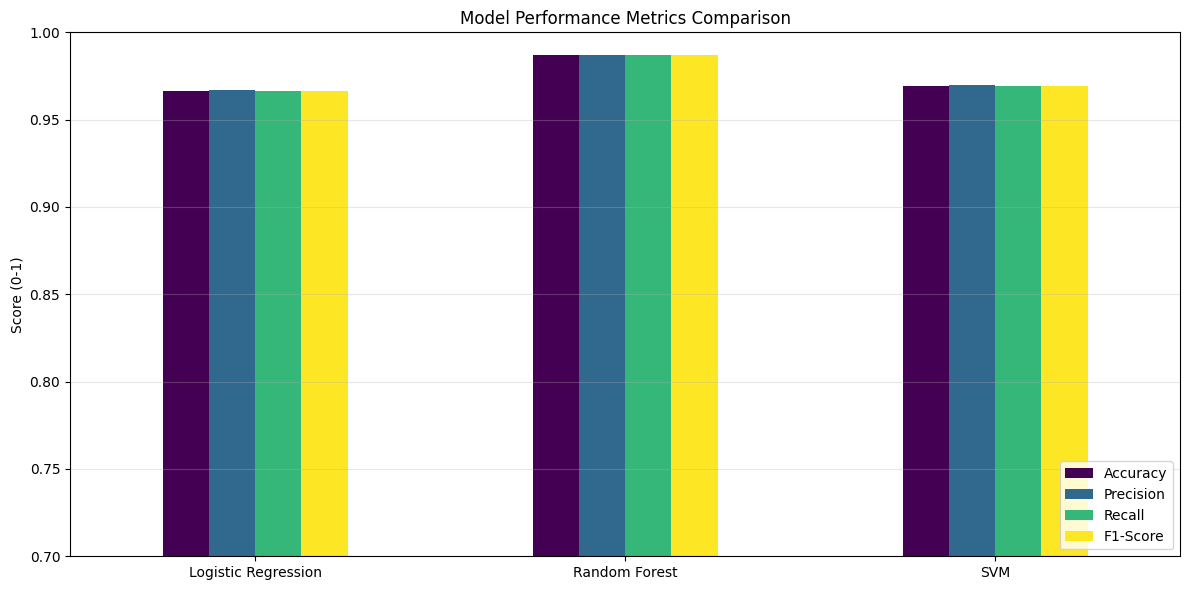

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
# IMPORT ALL METRICS HERE
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. DEFINE MODELS
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "SVM": SVC(kernel='rbf', random_state=42)
}

# -----------------------------
# 2. TRAINING LOOP
# -----------------------------
results = {}

print("🚀 Starting Model Training...\n")

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    
    # Calculate metrics individually
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Store for later
    results[name] = {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }
    
    print(f"✅ {name} Performance:")
    print(f"   Accuracy:  {acc:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print("-" * 60)

# -----------------------------
# 3. COMPARISON DATAFRAME
# -----------------------------
results_df = pd.DataFrame(results).T  # Transpose to make models rows
print("\n🏆 FINAL COMPARISON TABLE:")
print(results_df)

# -----------------------------
# 4. VISUALIZATION
# -----------------------------
results_df.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title("Model Performance Metrics Comparison")
plt.ylabel("Score (0-1)")
plt.ylim(0.7, 1.0)  # Zoom in on high scores
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
y_train_binary = (y_train != 'Normal').astype(int)
y_test_binary = (y_test != 'Normal').astype(int)

# Filter Training Data: Train mostly on "Normal" samples
# This helps the model learn the baseline of "Good" traffic.
X_train_normal = X_train[y_train == 'Normal']

print(f"Original Train Size: {X_train.shape}")
print(f"Normal-Only Train Size (for Anomaly Detection): {X_train_normal.shape}")
print("-" * 50)

Original Train Size: (15779, 114)
Normal-Only Train Size (for Anomaly Detection): (6806, 114)
--------------------------------------------------


In [27]:
print("🌲 Training Isolation Forest...")

# contamination='auto' or distinct percentage of attacks (e.g., 0.05)
iso_forest = IsolationForest(n_estimators=100, contamination=0.1, random_state=42, n_jobs=-1)
iso_forest.fit(X_train_normal)  # Fit on Normal data

# Predict on TEST set
# Isolation Forest returns: 1 (Normal), -1 (Anomaly)
iso_preds_raw = iso_forest.predict(X_test)

# Convert to our format: 0 (Normal), 1 (Attack)
iso_preds = np.where(iso_preds_raw == 1, 0, 1)

print("✅ Isolation Forest Results:")
print(classification_report(y_test_binary, iso_preds, target_names=['Normal', 'Anomaly']))
print("-" * 50)

🌲 Training Isolation Forest...
✅ Isolation Forest Results:
              precision    recall  f1-score   support

      Normal       0.80      0.91      0.85      1459
     Anomaly       0.92      0.83      0.87      1923

    accuracy                           0.86      3382
   macro avg       0.86      0.87      0.86      3382
weighted avg       0.87      0.86      0.87      3382

--------------------------------------------------


In [28]:
print("🔷 Training K-Means...")

# Use 1 cluster to find the "Center" of normal traffic
kmeans = KMeans(n_clusters=1, random_state=42, n_init=10)
kmeans.fit(X_train_normal)

# Calculate distances of Test Data to the center
distances = kmeans.transform(X_test)

# Define Threshold: Points farthest away are anomalies
# We use the 90th percentile of distance as the cutoff
threshold = np.percentile(distances, 90)
kmeans_preds = (distances > threshold).astype(int).flatten()

print(f"Threshold Distance: {threshold:.4f}")
print("✅ K-Means Anomaly Detection Results:")
print(classification_report(y_test_binary, kmeans_preds, target_names=['Normal', 'Anomaly']))

🔷 Training K-Means...
Threshold Distance: 8.3211
✅ K-Means Anomaly Detection Results:
              precision    recall  f1-score   support

      Normal       0.47      0.98      0.63      1459
     Anomaly       0.91      0.16      0.27      1923

    accuracy                           0.51      3382
   macro avg       0.69      0.57      0.45      3382
weighted avg       0.72      0.51      0.43      3382



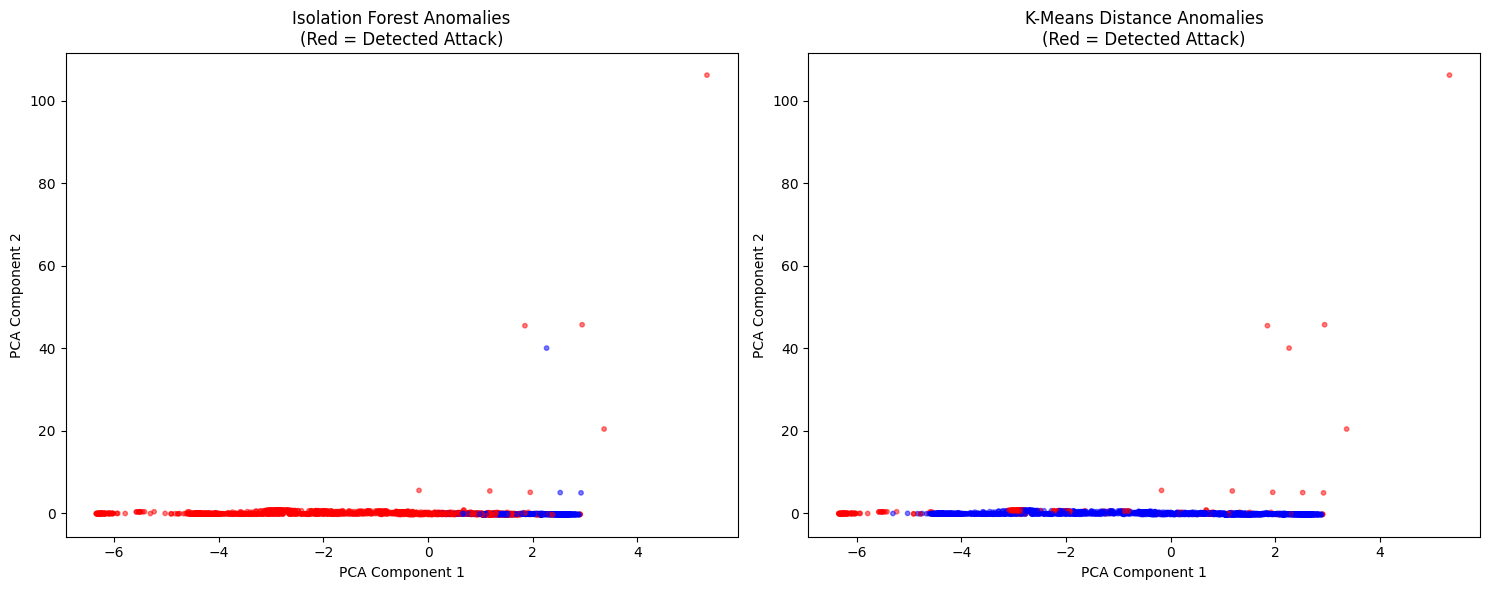

The Red points in the graphs represent what the AI thinks are attacks &The Blue points are what it considers normal traffic.


In [29]:
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

plt.figure(figsize=(15, 6))

# Plot Isolation Forest
plt.subplot(1, 2, 1)
colors = ['blue' if p == 0 else 'red' for p in iso_preds]
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=colors, alpha=0.5, s=10)
plt.title('Isolation Forest Anomalies\n(Red = Detected Attack)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

# Plot K-Means
plt.subplot(1, 2, 2)
colors_k = ['blue' if p == 0 else 'red' for p in kmeans_preds]
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=colors_k, alpha=0.5, s=10)
plt.title('K-Means Distance Anomalies\n(Red = Detected Attack)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.tight_layout()
plt.show()
print("The Red points in the graphs represent what the AI thinks are attacks &The Blue points are what it considers normal traffic.")

In [30]:
print("🏆 Selecting Best Model...")
best_model_name = "Random Forest" 
print(f"Selected Model: {best_model_name}")

🏆 Selecting Best Model...
Selected Model: Random Forest


In [31]:
print("\n⚙️ Starting Hyperparameter Tuning (GridSearchCV)...")
print("   (This helps find the optimal settings for the Random Forest)")

# Define the "Grid" of settings to test
# n_estimators: Number of trees
# max_depth: How deep each tree can grow (controls overfitting)
# min_samples_split: Minimum samples required to split a node
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Initialize Grid Search
# cv=3 means "Cross-Validation": splits training data into 3 parts to validate
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=3, n_jobs=-1, scoring='f1_weighted', verbose=1)

# Fit to training data
grid_search.fit(X_train, y_train)

# Get Best Parameters
best_rf = grid_search.best_estimator_
print(f"\n✅ Best Parameters Found: {grid_search.best_params_}")


⚙️ Starting Hyperparameter Tuning (GridSearchCV)...
   (This helps find the optimal settings for the Random Forest)
Fitting 3 folds for each of 18 candidates, totalling 54 fits

✅ Best Parameters Found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [32]:
print("\n📊 Evaluating Tuned Model on Test Data...")
y_pred_tuned = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_tuned))


📊 Evaluating Tuned Model on Test Data...
              precision    recall  f1-score   support

         DoS       1.00      0.99      1.00      1119
      Normal       0.98      0.99      0.98      1459
       Probe       0.99      0.99      0.99       363
         R2L       0.97      0.96      0.96       433
         U2R       0.75      0.75      0.75         8

    accuracy                           0.99      3382
   macro avg       0.94      0.94      0.94      3382
weighted avg       0.99      0.99      0.99      3382



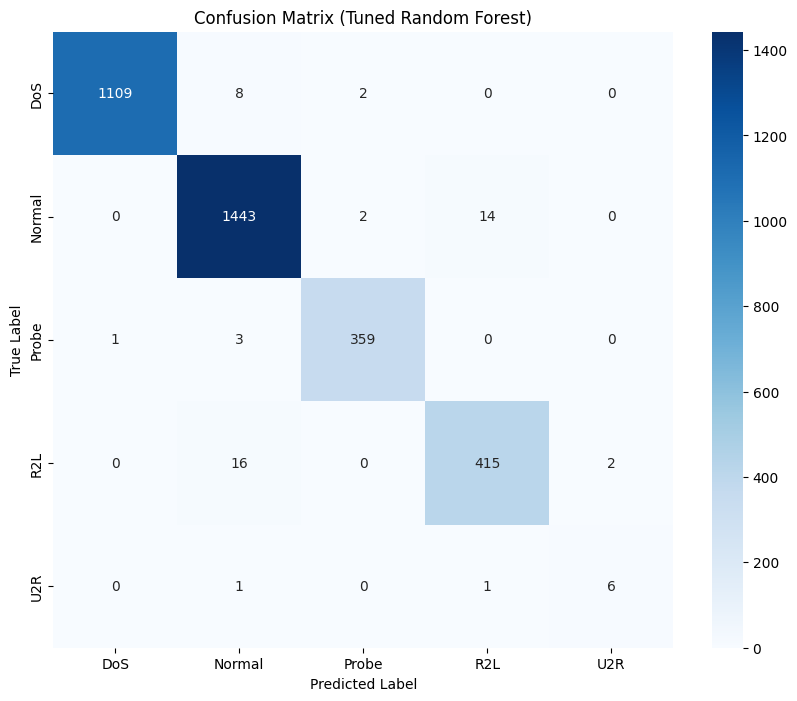

In [33]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_tuned, labels=best_rf.classes_)

# Plot using Seaborn for better visuals
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_rf.classes_, yticklabels=best_rf.classes_)
plt.title('Confusion Matrix (Tuned Random Forest)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

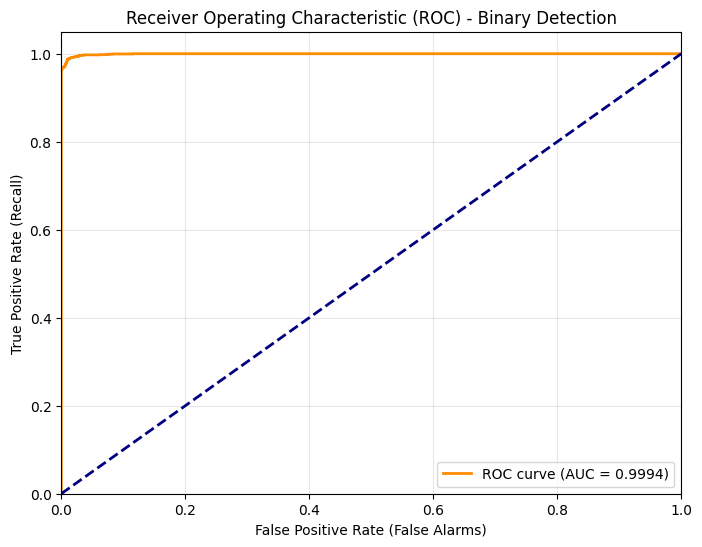

🚀 Final AUC Score: 0.9994


In [34]:
y_test_bin = (y_test != 'Normal').astype(int)
y_prob_attack = best_rf.predict_proba(X_test)

# We need the probability of "Not Normal" (sum of all attack probs)
# Get index of 'Normal' class
normal_index = list(best_rf.classes_).index('Normal')
# Prob of attack = 1 - Prob of Normal
y_prob_bin = 1 - y_prob_attack[:, normal_index]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_bin, y_prob_bin)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) - Binary Detection')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"🚀 Final AUC Score: {roc_auc:.4f}")

SENTINELNET - COMPLETE PIPELINE

[Week 1-2] Loading and preprocessing data...
✅ Data loaded: (22544, 41)
[Week 3] Creating new features...
✅ Features created
[Week 4] Splitting and preprocessing data...
✅ Train: (15779, 117) | Val: (3383, 117) | Test: (3382, 117)
[Week 5-6] Training and tuning Random Forest...
✅ Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 50}
[Week 7] Generating alerts...
✅ Total: 3382 | Attacks: 1915 | Normal: 1467
[Week 8] Creating dashboard...
✅ Dashboard saved as: Dashboard_20251216_193230.png


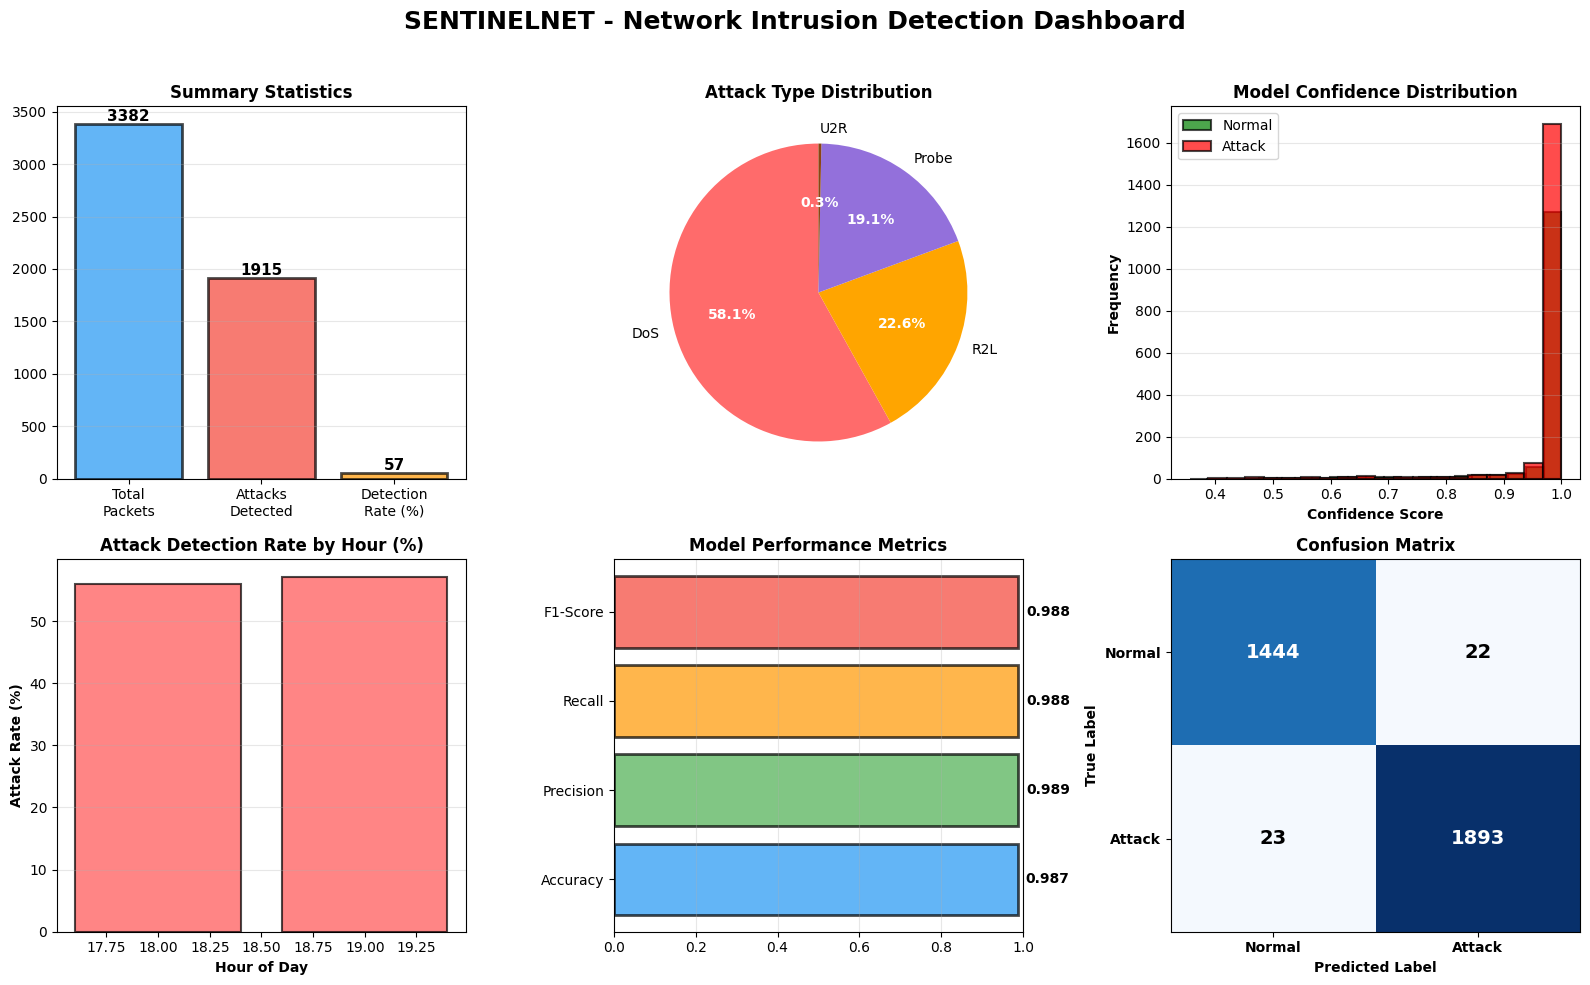


SENTINELNET - FINAL SUMMARY REPORT
Total Packets Analyzed:      3,382
Attacks Detected:            1,915 (56.6%)
Normal Traffic:              1,467 (43.4%)

CONFUSION MATRIX:
  True Negatives (TN):       1,444  (Correctly identified normal)
  True Positives (TP):       1,893  (Correctly identified attacks)
  False Positives (FP):      22  (Wrongly flagged as attack)
  False Negatives (FN):      23  (Missed attacks)

PERFORMANCE METRICS:
  Accuracy:  0.9867  (Overall correctness)
  Precision: 0.9885  (Trust in alerts)
  Recall:    0.9880    (Detection rate)
  F1-Score:  0.9883      (Harmonic mean)
✅ PIPELINE COMPLETE!


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

print("="*70)
print("SENTINELNET - COMPLETE PIPELINE")
print("="*70)

# =============================================
# WEEK 1-2: LOAD & PREPROCESS DATA
# =============================================
print("\n[Week 1-2] Loading and preprocessing data...")

file_path = r"C:\Users\hp\OneDrive\Desktop\anshnew\infosys\nsl-kdd\KDDTest+.txt"
df = pd.read_csv(file_path, header=None)

# Assign 41 feature names + label columns
feature_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login",
    "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate"
]

df.columns = feature_names + ["attack", "difficulty_level"]

# Map attacks to categories
dos_attacks = ['back','land','neptune','pod','smurf','teardrop','apache2',
               'mailbomb','processtable','udpstorm','worm']
probe_attacks = ['satan','ipsweep','nmap','portsweep','mscan','saint']
r2l_attacks = ['guess_passwd','ftp_write','imap','phf','multihop','warezmaster',
               'warezclient','spy','xlock','xsnoop','snmpgetattack','snmpguess',
               'httptunnel','sendmail','named']
u2r_attacks = ['rootkit','perl','loadmodule','ps','sqlattack','buffer_overflow']

def map_attack_category(label):
    if label in dos_attacks: return "DoS"
    elif label in probe_attacks: return "Probe"
    elif label in r2l_attacks: return "R2L"
    elif label in u2r_attacks: return "U2R"
    else: return "Normal"

df["attack_category"] = df["attack"].apply(map_attack_category)

# Remove duplicates and drop irrelevant columns
df.drop_duplicates(inplace=True)
df.drop(columns=[col for col in ["num_outbound_cmds", "is_host_login", "difficulty_level"] 
                 if col in df.columns], inplace=True)

# Handle missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

print(f"✅ Data loaded: {df.shape}")

# =============================================
# WEEK 3: FEATURE ENGINEERING
# =============================================
print("[Week 3] Creating new features...")

df["total_bytes"] = df["src_bytes"] + df["dst_bytes"]
df["byte_ratio"] = (df["src_bytes"] + 1) / (df["dst_bytes"] + 1)
df["total_error_rate"] = (df["serror_rate"] + df["rerror_rate"] + 
                          df["srv_serror_rate"] + df["srv_rerror_rate"]) / 4

print("✅ Features created")

# =============================================
# WEEK 4: SPLIT & PREPROCESS
# =============================================
print("[Week 4] Splitting and preprocessing data...")

# Define features
categorical_features = ["protocol_type", "service", "flag"]
numeric_features = [col for col in df.columns 
                   if col not in categorical_features + ["attack", "attack_category"]]

# Ensure features exist
categorical_features = [c for c in categorical_features if c in df.columns]
numeric_features = [c for c in numeric_features if c in df.columns]

# Separate features and target
X = df.drop(columns=["attack", "attack_category"])
y = df["attack_category"]

# Train-test split (70/15/15)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, 
                                                   random_state=42, stratify=y_temp)

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop"
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
X_val = preprocessor.transform(X_val)

print(f"✅ Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

# =============================================
# WEEK 5-6: TRAIN & TUNE MODEL
# =============================================
print("[Week 5-6] Training and tuning Random Forest...")

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=3, n_jobs=-1, scoring='f1_weighted', verbose=0)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"✅ Best Parameters: {grid_search.best_params_}")

# =============================================
# WEEK 7: GENERATE ALERTS
# =============================================
print("[Week 7] Generating alerts...")

y_pred_test = best_rf.predict(X_test)
y_prob_test = best_rf.predict_proba(X_test).max(axis=1)

packet_ids = np.arange(len(X_test))
timestamps = [datetime.now() - timedelta(seconds=int(i)) for i in range(len(X_test))]
y_test_labels = y_test.reset_index(drop=True)

alerts_df = pd.DataFrame({
    'packet_id': packet_ids,
    'timestamp': timestamps,
    'predicted_class': y_pred_test,
    'confidence': y_prob_test,
    'actual_class': y_test_labels.values,
    'is_attack': (y_pred_test != 'Normal').astype(int),
    'is_correct': (y_pred_test == y_test_labels.values).astype(int)
})

attack_df = alerts_df[alerts_df['is_attack'] == 1].copy()
normal_df = alerts_df[alerts_df['is_attack'] == 0].copy()

print(f"✅ Total: {len(alerts_df)} | Attacks: {len(attack_df)} | Normal: {len(normal_df)}")

# =============================================
# WEEK 8: DASHBOARD
# =============================================
print("[Week 8] Creating dashboard...")

fig = plt.figure(figsize=(16, 10))

# 1. Summary Stats
ax1 = plt.subplot(2, 3, 1)
stats_labels = ['Total\nPackets', 'Attacks\nDetected', 'Detection\nRate (%)']
stats_values = [len(alerts_df), len(attack_df), (len(attack_df)/len(alerts_df)*100)]
colors_stats = ['#2196F3', '#F44336', '#FF9800']
bars = ax1.bar(stats_labels, stats_values, color=colors_stats, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_title('Summary Statistics', fontweight='bold', fontsize=12)
for i, (bar, val) in enumerate(zip(bars, stats_values)):
    ax1.text(bar.get_x() + bar.get_width()/2, val, f'{val:.0f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# 2. Attack Type Distribution
ax2 = plt.subplot(2, 3, 2)
attack_counts = alerts_df[alerts_df['is_attack'] == 1]['predicted_class'].value_counts()
colors_pie = ['#FF6B6B', '#FFA500', '#9370DB', '#8B4513']
wedges, texts, autotexts = ax2.pie(attack_counts.values, labels=attack_counts.index, autopct='%1.1f%%', 
        colors=colors_pie[:len(attack_counts)], startangle=90)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax2.set_title('Attack Type Distribution', fontweight='bold', fontsize=12)

# 3. Confidence Distribution
ax3 = plt.subplot(2, 3, 3)
ax3.hist(alerts_df[alerts_df['is_attack'] == 0]['confidence'], bins=20, alpha=0.7, 
         label='Normal', color='green', edgecolor='black', linewidth=1.5)
ax3.hist(alerts_df[alerts_df['is_attack'] == 1]['confidence'], bins=20, alpha=0.7, 
         label='Attack', color='red', edgecolor='black', linewidth=1.5)
ax3.set_title('Model Confidence Distribution', fontweight='bold', fontsize=12)
ax3.set_xlabel('Confidence Score', fontweight='bold')
ax3.set_ylabel('Frequency', fontweight='bold')
ax3.legend(loc='upper left')
ax3.grid(axis='y', alpha=0.3)

# 4. Hourly Attack Rate
ax4 = plt.subplot(2, 3, 4)
hourly_attacks = alerts_df[alerts_df['is_attack'] == 1].groupby(
    alerts_df['timestamp'].dt.hour).size()
hourly_all = alerts_df.groupby(alerts_df['timestamp'].dt.hour).size()
hourly_rate = (hourly_attacks / hourly_all * 100).fillna(0)
bars_hourly = ax4.bar(hourly_rate.index, hourly_rate.values, color='#FF5252', alpha=0.7, edgecolor='black', linewidth=1.5)
ax4.set_title('Attack Detection Rate by Hour (%)', fontweight='bold', fontsize=12)
ax4.set_xlabel('Hour of Day', fontweight='bold')
ax4.set_ylabel('Attack Rate (%)', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# 5. Performance Metrics
ax5 = plt.subplot(2, 3, 5)
tp = ((alerts_df['is_attack'] == 1) & (alerts_df['is_correct'] == 1)).sum()
fp = ((alerts_df['is_attack'] == 1) & (alerts_df['is_correct'] == 0)).sum()
tn = ((alerts_df['is_attack'] == 0) & (alerts_df['is_correct'] == 1)).sum()
fn = ((alerts_df['is_attack'] == 0) & (alerts_df['is_correct'] == 0)).sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
colors_metrics = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
bars_metrics = ax5.barh(metrics, values, color=colors_metrics, alpha=0.7, edgecolor='black', linewidth=2)
ax5.set_xlim(0, 1)
ax5.set_title('Model Performance Metrics', fontweight='bold', fontsize=12)
for i, (bar, v) in enumerate(zip(bars_metrics, values)):
    ax5.text(v + 0.02, bar.get_y() + bar.get_height()/2, f'{v:.3f}', 
            va='center', fontweight='bold', fontsize=10)
ax5.grid(axis='x', alpha=0.3)

# 6. Confusion Matrix
ax6 = plt.subplot(2, 3, 6)
cm_matrix = [[tn, fp], [fn, tp]]
im = ax6.imshow(cm_matrix, cmap='Blues', aspect='auto', vmin=0)
ax6.set_xticks([0, 1])
ax6.set_yticks([0, 1])
ax6.set_xticklabels(['Normal', 'Attack'], fontweight='bold')
ax6.set_yticklabels(['Normal', 'Attack'], fontweight='bold')
ax6.set_ylabel('True Label', fontweight='bold')
ax6.set_xlabel('Predicted Label', fontweight='bold')
for i in range(2):
    for j in range(2):
        color_text = 'white' if cm_matrix[i][j] > (max(tp, tn)/2) else 'black'
        ax6.text(j, i, str(cm_matrix[i][j]), ha='center', va='center', 
                color=color_text, fontsize=14, fontweight='bold')
ax6.set_title('Confusion Matrix', fontweight='bold', fontsize=12)

# Overall title
fig.suptitle('SENTINELNET - Network Intrusion Detection Dashboard', 
            fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save dashboard
dashboard_file = f'Dashboard_{datetime.now().strftime("%Y%m%d_%H%M%S")}.png'
plt.savefig(dashboard_file, dpi=150, bbox_inches='tight')
print(f"✅ Dashboard saved as: {dashboard_file}")

plt.show()

# Print summary
print("\n" + "="*70)
print("SENTINELNET - FINAL SUMMARY REPORT")
print("="*70)
print(f"Total Packets Analyzed:      {len(alerts_df):,}")
print(f"Attacks Detected:            {len(attack_df):,} ({len(attack_df)/len(alerts_df)*100:.1f}%)")
print(f"Normal Traffic:              {len(normal_df):,} ({len(normal_df)/len(alerts_df)*100:.1f}%)")
print(f"\nCONFUSION MATRIX:")
print(f"  True Negatives (TN):       {tn:,}  (Correctly identified normal)")
print(f"  True Positives (TP):       {tp:,}  (Correctly identified attacks)")
print(f"  False Positives (FP):      {fp:,}  (Wrongly flagged as attack)")
print(f"  False Negatives (FN):      {fn:,}  (Missed attacks)")
print(f"\nPERFORMANCE METRICS:")
print(f"  Accuracy:  {accuracy:.4f}  (Overall correctness)")
print(f"  Precision: {precision:.4f}  (Trust in alerts)")
print(f"  Recall:    {recall:.4f}    (Detection rate)")
print(f"  F1-Score:  {f1:.4f}      (Harmonic mean)")
print("="*70)
print("✅ PIPELINE COMPLETE!")
print("="*70)